Proyek Analisis Data: Air Quality – Stasiun Changping, Beijing


Nama: Nathaniel Krisnahadi P

Email: cdcc239d6y2662@student.devacademy.id 

ID Dicoding: CDCC239D6Y2662


Dataset
Beijing Air Quality Data – Stasiun Changping  

Pertanyaan Bisnis
1. Bagaimana tren dan pola musiman konsentrasi PM2.5 di Stasiun Changping selama 2013–2017?
2. Bagaimana pengaruh kondisi cuaca (kecepatan angin, suhu, dan tekanan udara) terhadap konsentrasi PM2.5?


## 1. Menyiapkan Semua Library yang Dibutuhkan

Pada tahap ini, saya mengimpor seluruh library Python yang akan digunakan dalam proses analisis data, mulai dari manipulasi data, komputasi numerik, hingga visualisasi.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats


# Konfigurasi tampilan
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white'
})

SEASON_COLOR = {
    'Spring': '#4CAF50',
    'Summer': '#FF9800',
    'Autumn': '#CD853F',
    'Winter': '#2196F3'
}
AQI_COLOR = {
    'Good':                           '#00C853',
    'Moderate':                       '#FFD600',
    'Unhealthy for Sensitive Groups': '#FF6D00',
    'Unhealthy':                      '#D50000',
    'Very Unhealthy':                 '#6A1B9A',
    'Hazardous':                      '#37474F'
}



## 2. Data Wrangling

### 2.1 Gathering Data
Membaca dataset kualitas udara Stasiun Changping dari file CSV.


In [23]:
df_raw = pd.read_csv('./data/PRSA_Data_Changping_20130301-20170228.csv')

print(f" Dimensi dataset : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")
print(f" Periode         : {df_raw['year'].min()} – {df_raw['year'].max()}")
print(f" Stasiun         : {df_raw['station'].unique()[0]}")
df_raw.head()


 Dimensi dataset : 35064 baris × 18 kolom
 Periode         : 2013 – 2017
 Stasiun         : Changping


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


### 2.2 Assessing Data

In [ ]:
print("INFO DATASET")
print("\n")

df_raw.info()

INFO DATASET


<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  str    
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 4.8 MB


Statistik Deskriptif

In [12]:
df_raw.describe().round(2)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.00,35064.00,35064.00,35064.00,35064.00,34290.00,34482.00,34436.00,34397.00,33543.00,34460.00,35011.00,35014.00,35011.00,35013.00,35021.00
mean,17532.50,2014.66,6.52,15.73,11.50,71.10,94.66,14.96,44.18,1152.30,57.94,13.69,1007.76,1.51,0.06,1.85
std,10122.25,1.18,3.45,8.80,6.92,72.33,83.44,20.98,29.52,1103.06,54.32,11.37,10.23,13.82,0.75,1.31
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.85,100.00,0.21,-16.60,982.40,-35.10,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,18.00,34.00,2.00,22.00,500.00,15.64,3.40,999.30,-10.20,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,46.00,72.00,7.00,36.00,800.00,46.00,14.70,1007.40,1.80,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,100.00,131.00,18.00,60.36,1400.00,80.00,23.30,1016.00,14.20,0.00,2.30
max,35064.00,2017.00,12.00,31.00,23.00,882.00,999.00,310.00,226.00,10000.00,429.00,41.40,1036.50,27.20,52.10,10.00


cek missing values

In [15]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Jumlah Missing', ascending=False)
miss_df = miss_df[miss_df['Jumlah Missing'] > 0]
print(f"Kolom dengan missing value: {len(miss_df)}")
print()
print(miss_df)


Kolom dengan missing value: 12

       Jumlah Missing  Persentase (%)
CO               1521            4.34
PM2.5             774            2.21
NO2               667            1.90
SO2               628            1.79
O3                604            1.72
PM10              582            1.66
wd                140            0.40
DEWP               53            0.15
TEMP               53            0.15
RAIN               51            0.15
PRES               50            0.14
WSPM               43            0.12


In [16]:
# Cek duplikasi
print(f"Jumlah baris duplikat: {df_raw.duplicated().sum()}")


Jumlah baris duplikat: 0


**Insight – Assessing Data:**
- Dataset Stasiun Changping memiliki **35.064 records** data per jam dari Maret 2013 hingga Februari 2017.
- Terdapat missing values pada kolom polutan (PM2.5 ~2.2%, CO ~4.3%) dan variabel cuaca.
- `CO` memiliki persentase missing terbanyak (4.3%).
- Tidak ada data duplikat.
- Perlu dibuat kolom `datetime` dan `season` sebagai fitur waktu tambahan.


### 2.3 Cleaning Data

In [26]:
df = df_raw.copy()

# kolom datetime
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

# kolom musim
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter',  2:'Winter',
     3:'Spring', 4:'Spring',  5:'Spring',
     6:'Summer', 7:'Summer',  8:'Summer',
     9:'Autumn',10:'Autumn', 11:'Autumn'
})

# Imputasi missing values dengan median
num_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    
# 4. Kategori AQI 
def aqi_category(pm):
    if pm <= 12:      return 'Good'
    elif pm <= 35.4:  return 'Moderate'
    elif pm <= 55.4:  return 'Unhealthy for Sensitive Groups'
    elif pm <= 150.4: return 'Unhealthy'
    elif pm <= 250.4: return 'Very Unhealthy'
    else:             return 'Hazardous'

df['AQI_cat'] = df['PM2.5'].apply(aqi_category)

# tingkat polusi (untuk analisis lanjutan)
df['pollution_level'] = pd.cut(
    df['PM2.5'],
    bins=[0, 12, 35.4, 75, 150, np.inf],
    labels=['Rendah','Sedang','Tinggi','Sangat Tinggi','Berbahaya']
)

print(f"Cleaning selesai. Shape: {df.shape}")
print(f"Missing values tersisa: {df[num_cols].isnull().sum().sum()}")
print("\nDistribusi AQI Category:")
print(df['AQI_cat'].value_counts())


Cleaning selesai. Shape: (35064, 22)
Missing values tersisa: 0

Distribusi AQI Category:
AQI_cat
Unhealthy                         10946
Moderate                           9050
Good                               5480
Unhealthy for Sensitive Groups     5214
Very Unhealthy                     3279
Hazardous                          1095
Name: count, dtype: int64


Insight  Cleaning Data:
- Missing values diisi dengan median dipilih karena distribusi data polusi cenderung right-skewed sehingga median lebih representatif daripada mean.
- Kolom datetime digabung dari kolom year, month, day, hour untuk memudahkan analisis temporal.
- Kategori AQI dibuat berdasarkan standar EPA  membagi PM2.5 ke dalam 6 tingkat bahaya.
- Hasil: 35.8% pengukuran masuk kategori Unhealthy, menunjukkan kondisi udara Changping yang cukup mengkhawatirkan.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Polutan Utama


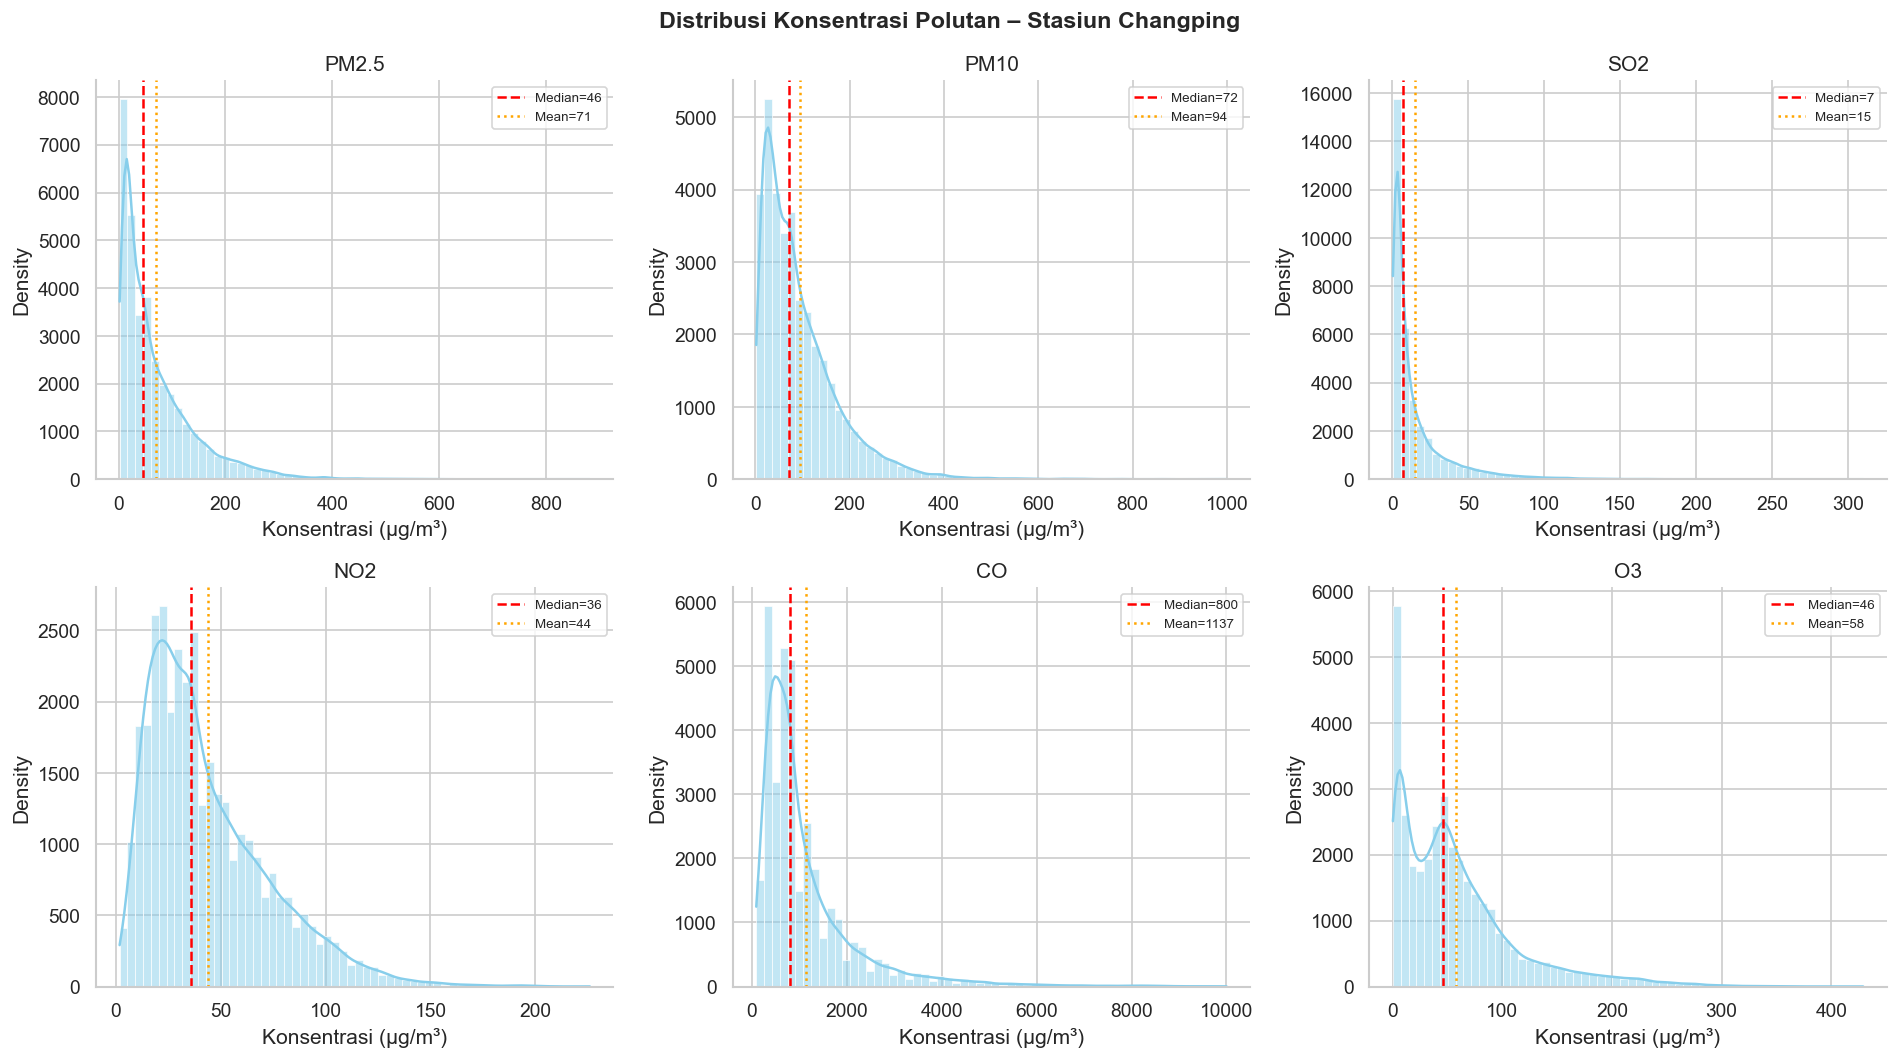

In [33]:
# pollutants = ['PM2.5','PM10','SO2','NO2','CO','O3']
# colors_p   = ['#2196F3','#E91E63','#FF9800','#4CAF50','#9C27B0','#00BCD4']

# fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# fig.suptitle('Distribusi Konsentrasi Polutan – Stasiun Changping',
#              fontsize=14, fontweight='bold')

# for idx, (pol, col) in enumerate(zip(pollutants, colors_p)):
#     ax = axes[idx//3, idx%3]
#     data = df[pol].clip(upper=df[pol].quantile(0.99))
#     ax.hist(data, bins=60, color=col, alpha=0.6, density=True, edgecolor='white', lw=0.3)
#     data.plot.kde(ax=ax, color='black', lw=2)
#     ax.axvline(df[pol].median(), color='red',    ls='--', lw=1.5, label=f'Median={df[pol].median():.0f}')
#     ax.axvline(df[pol].mean(),   color='orange', ls=':',  lw=1.5, label=f'Mean={df[pol].mean():.0f}')
#     ax.set_title(pol, fontweight='bold', fontsize=12)
#     ax.set_xlabel('Konsentrasi (µg/m³)'); ax.set_ylabel('Density')
#     ax.legend(fontsize=8)

# plt.tight_layout()
# plt.savefig('distribusi_polutan.png', bbox_inches='tight', dpi=120)
# plt.show()
# print("\nSeluruh polutan menunjukkan distribusi right-skewed — nilai ekstrem tinggi sering terjadi di Changping.")


pollutants = ['PM2.5','PM10','SO2','NO2','CO','O3']

plt.figure(figsize=(16,9))

for i, pol in enumerate(pollutants, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[pol], bins=60, kde=True, color='skyblue')
    plt.axvline(df[pol].median(), color='red', ls='--', label=f'Median={df[pol].median():.0f}')
    plt.axvline(df[pol].mean(),   color='orange', ls=':',  label=f'Mean={df[pol].mean():.0f}')
    plt.title(pol)
    plt.xlabel('Konsentrasi (µg/m³)')
    plt.ylabel('Density')
    plt.legend(fontsize=8)

plt.suptitle('Distribusi Konsentrasi Polutan – Stasiun Changping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 Proporsi Kategori AQI

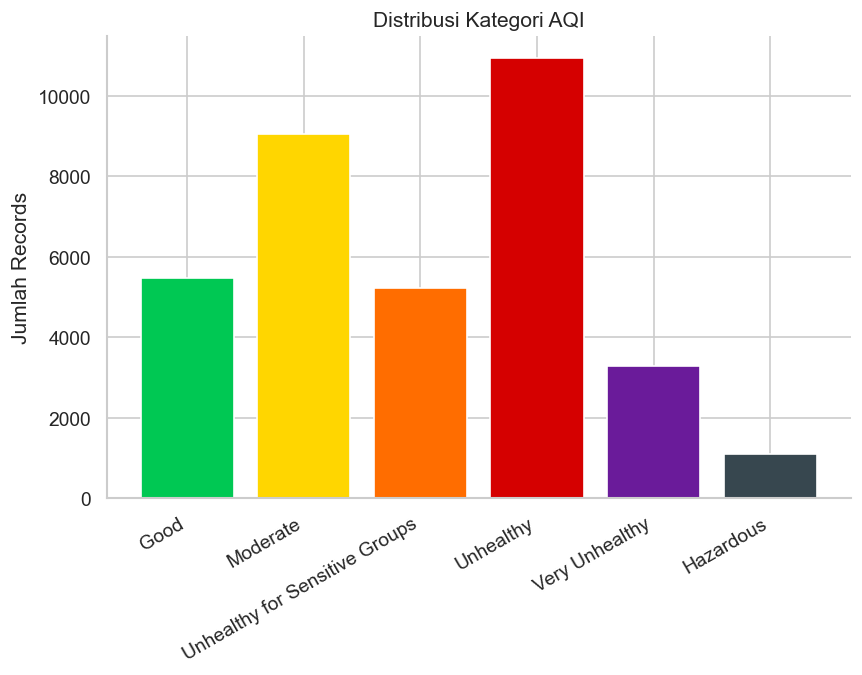

In [39]:
# Bar chart

aqi_order = ['Good','Moderate','Unhealthy for Sensitive Groups',
             'Unhealthy','Very Unhealthy','Hazardous']
aqi_counts = df['AQI_cat'].value_counts().reindex(aqi_order)

plt.figure(figsize=(8,5))
plt.bar(aqi_order, aqi_counts, color=[AQI_COLOR[c] for c in aqi_order])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Jumlah Records')
plt.title('Distribusi Kategori AQI')
plt.show()



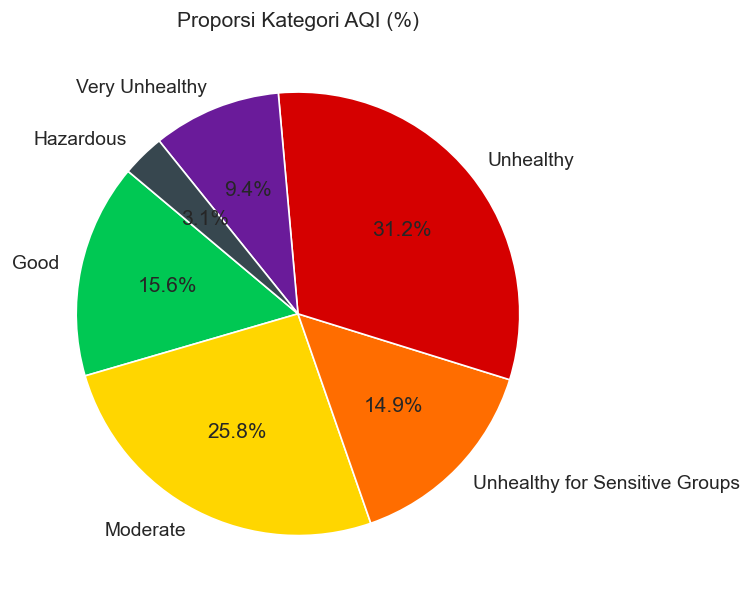

In [40]:
# pie chart
plt.figure(figsize=(6,6))
plt.pie(aqi_counts, labels=aqi_order, colors=[AQI_COLOR[c] for c in aqi_order],
        autopct='%1.1f%%', startangle=140)
plt.title('Proporsi Kategori AQI (%)')
plt.show()


### 3.3 Tren Temporal PM2.5

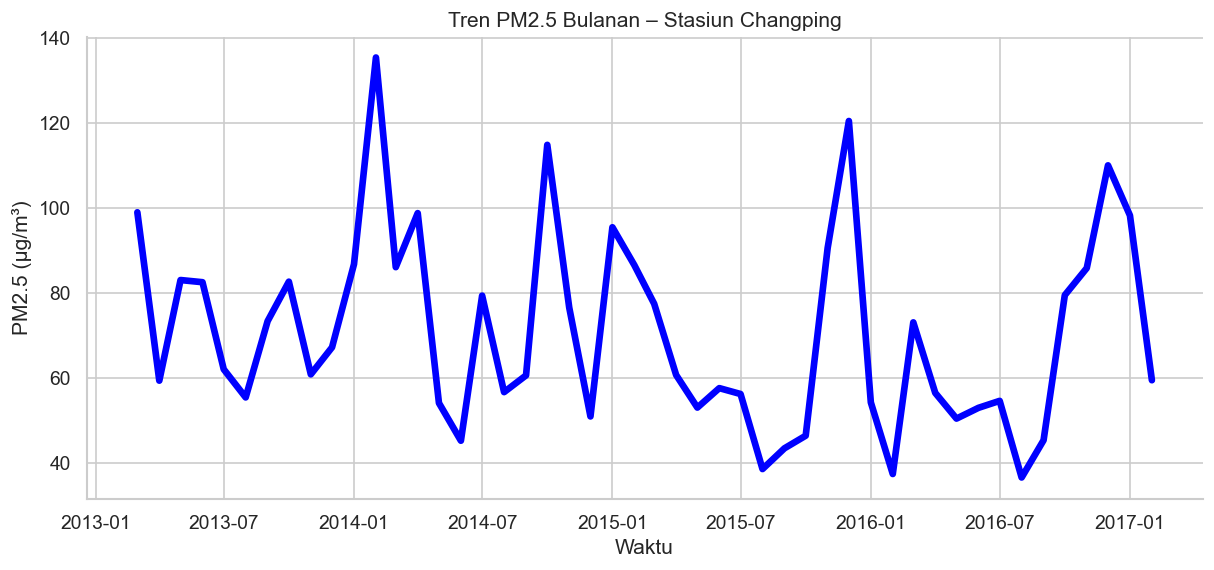

In [46]:
# Hitung rata-rata bulanan PM2.5
monthly = df.groupby(['year','month'])['PM2.5'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly = monthly.sort_values('date')

# Plot 
plt.figure(figsize=(12,5))
plt.plot(monthly['date'], monthly['PM2.5'], color='blue', lw=4)
plt.xlabel('Waktu')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Tren PM2.5 Bulanan – Stasiun Changping')
plt.show()

### 3.4 Pola Harian dan Heatmap Bulan × Jam

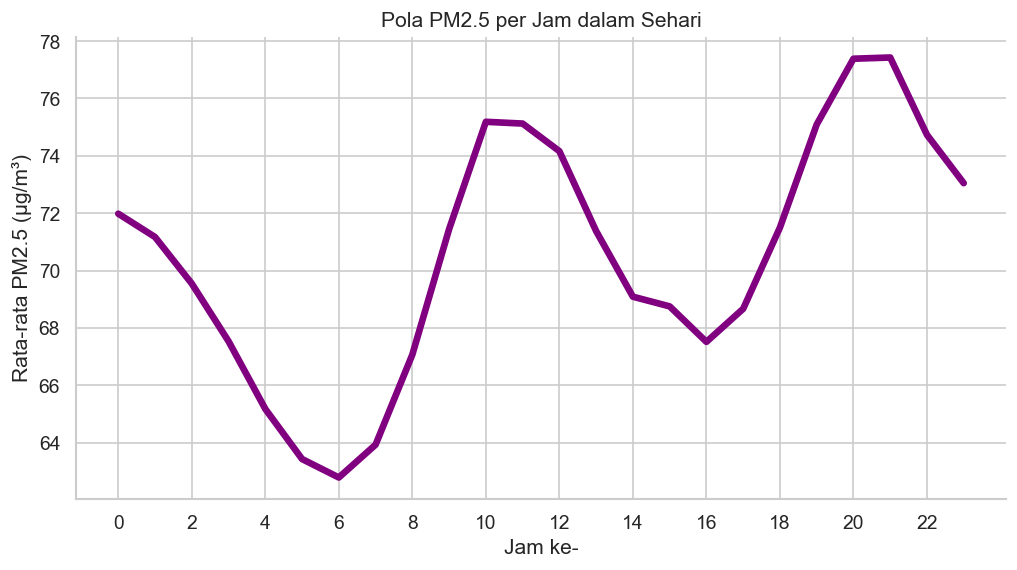

Jam puncak: 21:00 (77.4 µg/m³)
Jam terendah: 6:00 (62.8 µg/m³)


In [45]:
# Hitung rata-rata PM2.5 per jam
hourly_pm = df.groupby('hour')['PM2.5'].mean()

# Plot sederhana
plt.figure(figsize=(10,5))
plt.plot(hourly_pm.index, hourly_pm.values, color='purple', lw=4)
plt.xlabel('Jam ke-')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.title('Pola PM2.5 per Jam dalam Sehari')
plt.xticks(range(0,24,2))
plt.show()

print(f"Jam puncak: {hourly_pm.idxmax()}:00 ({hourly_pm.max():.1f} µg/m³)")
print(f"Jam terendah: {hourly_pm.idxmin()}:00 ({hourly_pm.min():.1f} µg/m³)")


### 3.5 Korelasi Antar Variabel

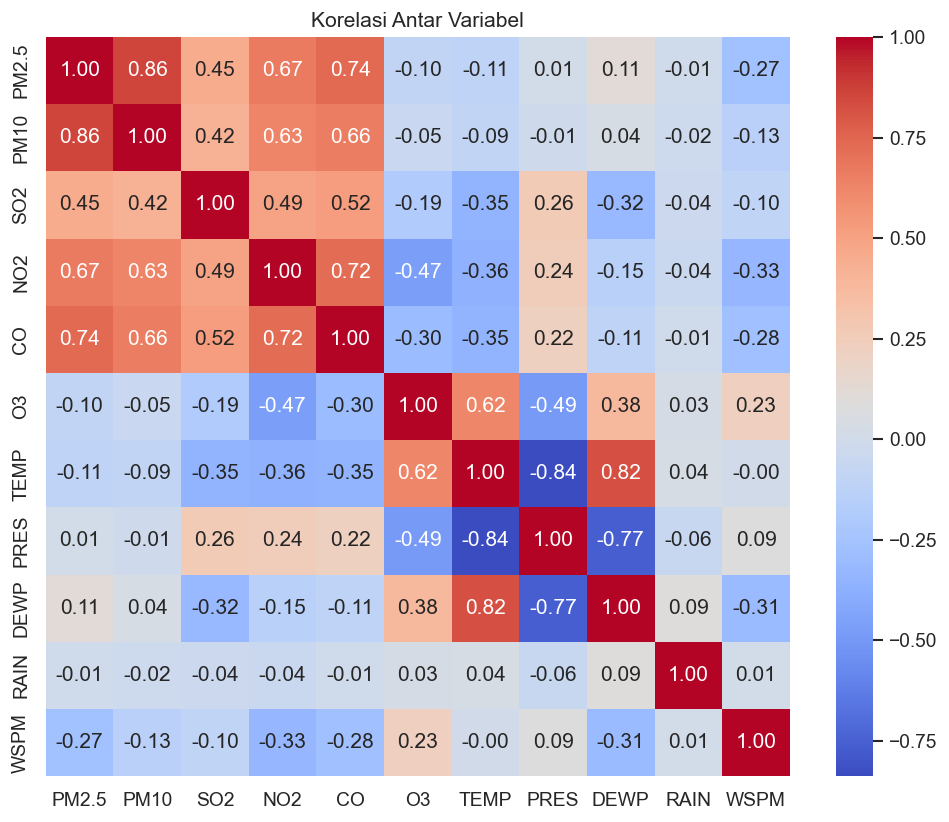


Korelasi dengan PM2.5:
PM10    0.858
SO2     0.453
NO2     0.669
CO      0.738
O3     -0.098
TEMP   -0.111
PRES    0.009
DEWP    0.114
RAIN   -0.008
WSPM   -0.270
Name: PM2.5, dtype: float64


In [47]:
corr_cols = ['PM2.5','PM10','SO2','NO2','CO','O3', 'TEMP','PRES','DEWP','RAIN','WSPM']

#  matriks korelasi
corr = df[corr_cols].corr()

# Plot heatmap sederhana
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Variabel')
plt.show()

# Korelasi dengan PM2.5
print("\nKorelasi dengan PM2.5:")
print(corr['PM2.5'].drop('PM2.5').round(3))

 4. Visualization & Explanatory Analysis

 Pertanyaan 1: Bagaimana tren dan pola musiman konsentrasi PM2.5 di Stasiun Changping selama 2013–2017?


In [48]:
season_order = ['Spring','Summer','Autumn','Winter']
season_stats = df.groupby('season').agg(
    Avg_PM25 =('PM2.5','mean'),
    Std_PM25 =('PM2.5','std'),
    Median_PM25=('PM2.5','median'),
    Pct_Hazardous=('PM2.5', lambda x: (x>250).mean()*100)
).reindex(season_order).round(2)
print(season_stats)


        Avg_PM25  Std_PM25  Median_PM25  Pct_Hazardous
season                                                
Spring     70.91     65.99         50.0           2.52
Summer     56.38     50.57         42.0           0.41
Autumn     71.70     70.25         46.0           3.45
Winter     83.45     91.47         46.0           6.17


Summer : udara paling bersih, jarang mencapai level bahaya
Winter : udara paling kotor, rata-rata polusi PM25 tinggi, variasi besar dan paling sering bahaya
Sprig & Autum : kualitas udara sedang, tapi ada risiko polusi tinggi

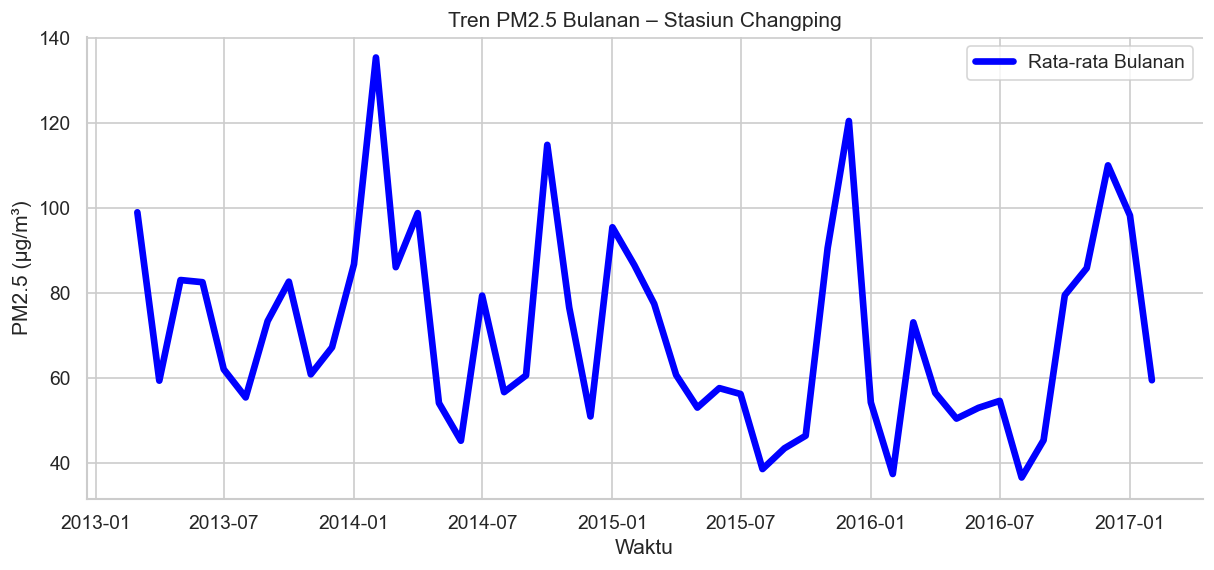

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16192\214521574.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_stats.index, y=season_stats.values, palette='Set2')


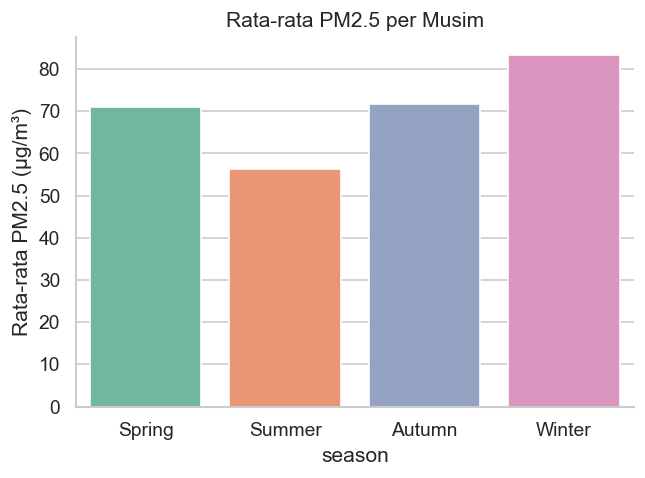

In [51]:
#  Tren bulanan PM2.5 
monthly = df.groupby(['year','month'])['PM2.5'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly = monthly.sort_values('date')

plt.figure(figsize=(12,5))
plt.plot(monthly['date'], monthly['PM2.5'], color='blue', lw=4, label='Rata-rata Bulanan')
plt.xlabel('Waktu'); plt.ylabel('PM2.5 (µg/m³)')
plt.title('Tren PM2.5 Bulanan – Stasiun Changping')
plt.legend()
plt.show()

#  Bar chart per musim 
season_order = ['Spring','Summer','Autumn','Winter']
season_stats = df.groupby('season')['PM2.5'].mean().reindex(season_order)

plt.figure(figsize=(6,4))
sns.barplot(x=season_stats.index, y=season_stats.values, palette='Set2')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.title('Rata-rata PM2.5 per Musim')
plt.show()

 Kesimpulan Pertanyaan 1

Polusi PM2.5 di Changping dipengaruhi musim, dengan puncak polusi di musim dingin dan udara relatif bersih di musim panas



Pertanyaan 2: 
Bagaimana pengaruh kondisi cuaca (kecepatan angin, suhu, tekanan udara) terhadap konsentrasi PM2.5?

In [54]:
# Uji korelasi Spearman 
weather_vars = ['TEMP','PRES','DEWP','RAIN','WSPM']
corr_results = {}
for var in weather_vars:
    r, p = stats.spearmanr(df['PM2.5'], df[var])
    corr_results[var] = {'Korelasi Spearman': round(r, 3), 'p-value': round(p, 4),
                         'Signifikan?': 'Ya' if p < 0.05 else 'Tidak'}

print("Uji Korelasi Spearman: Cuaca vs PM2.5")
print(pd.DataFrame(corr_results).T)


Uji Korelasi Spearman: Cuaca vs PM2.5
     Korelasi Spearman p-value Signifikan?
TEMP            -0.035     0.0          Ya
PRES            -0.057     0.0          Ya
DEWP             0.214     0.0          Ya
RAIN            -0.005  0.3891       Tidak
WSPM            -0.327     0.0          Ya


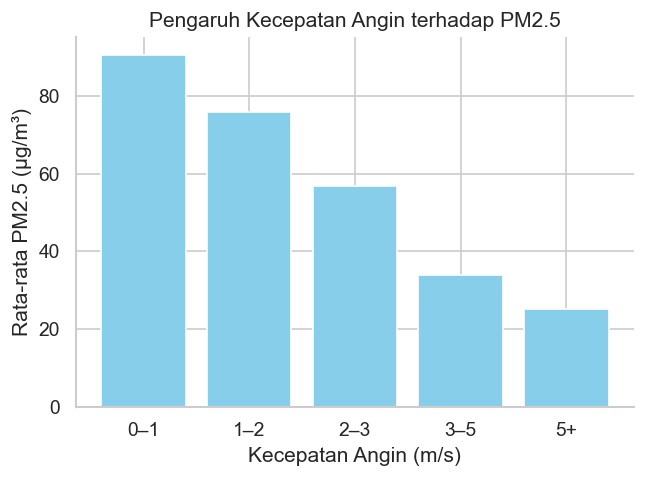

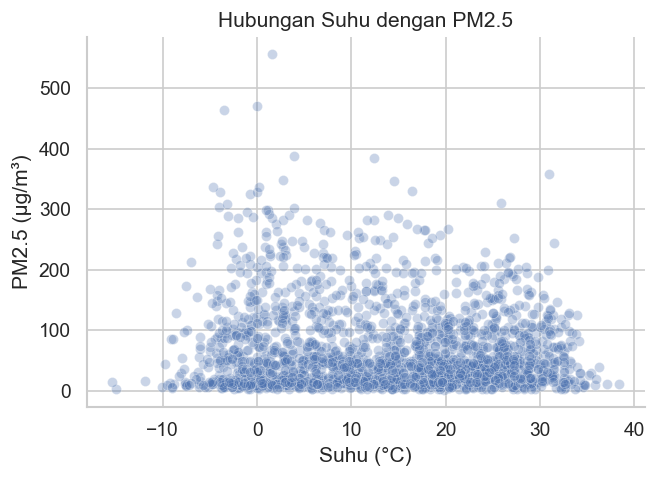

In [58]:
# Kecepatan angin vs PM2.5 (bar chart) 
ws_bins = pd.cut(df['WSPM'], bins=[0,1,2,3,5,14], labels=['0–1','1–2','2–3','3–5','5+'])
ws_pm   = df.groupby(ws_bins)['PM2.5'].mean()

plt.figure(figsize=(6,4))
plt.bar(ws_pm.index, ws_pm.values, color='skyblue', edgecolor='white')
plt.xlabel('Kecepatan Angin (m/s)')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.title('Pengaruh Kecepatan Angin terhadap PM2.5')
plt.show()

# Suhu vs PM2.5 (scatter plot)
sample = df.sample(2000, random_state=42)  # ambil sampel biar ringan
plt.figure(figsize=(6,4))
sns.scatterplot(data=sample, x='TEMP', y='PM2.5', alpha=0.3)
plt.xlabel('Suhu (°C)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hubungan Suhu dengan PM2.5')
plt.show()

Kesimpulan Pertanyaan 2:

Faktor cuaca memang mempengaruhi polusi PM2.5. Angin kencang dan hujan membantu membersihkan udara, sedangkan suhu rendah dan kondisi musim dingin membuat polusi lebih parah 

## 5. Analisis Lanjutan: Clustering Manual (Binning)


Rendah (≤ 12 µg/m³): udara aman, bebas beraktivitas di luar.
Sedang (12–35 µg/m³): tetap waspada, tapi masih relatif aman.
Tinggi (35–75 µg/m³): sebaiknya kurangi aktivitas berat di luar ruangan.
Sangat Tinggi (75–150 µg/m³): gunakan masker dan hindari terlalu lama di luar.
Berbahaya (> 150 µg/m³): sebaiknya tetap di dalam ruangan dan gunakan air purifier.

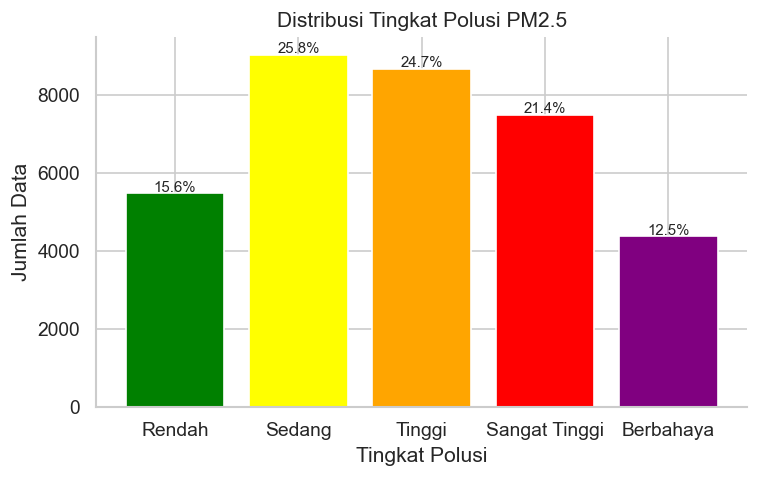

In [61]:
# Hitung jumlah tiap level polusi
level_order  = ['Rendah','Sedang','Tinggi','Sangat Tinggi','Berbahaya']
cnt = df['pollution_level'].value_counts().reindex(level_order)
pct = cnt / cnt.sum() * 100

# Plot bar 
plt.figure(figsize=(7,4))
bars = plt.bar(level_order, cnt.values, color=['green','yellow','orange','red','purple'])
plt.xlabel('Tingkat Polusi')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Tingkat Polusi PM2.5')

#  persentase di atas batang
for bar, p in zip(bars, pct.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{p:.1f}%', ha='center', fontsize=9)

plt.show()

Hasil Temuan
- Polusi PM2.5 di Changping paling buruk di musim dingin, paling bersih di musim panas.
- Selama 2013–2017 tidak ada penurunan nyata, polusi tetap tinggi.
- Angin kencang membantu menurunkan polusi, sedangkan angin lemah dan suhu rendah membuat polusi menumpuk.
- Hujan hanya sedikit berpengaruh terhadap penurunan PM2.5.

SOLUSI:
- Buat sistem peringatan dini saat cuaca berisiko (angin lemah, suhu rendah, tekanan tinggi).
- Perketat pembatasan emisi kendaraan dan industri di musim dingin.
- Dorong penggunaan energi bersih untuk pemanas rumah tangga.
- Fokus monitoring di jam malam karena sering muncul puncak polusi harian.

Polusi PM2.5 di Changping sangat dipengaruhi musim dan cuaca, dengan puncak di musim dingin, sehingga perlu langkah pencegahan khusus terutama pada periode tersebut.

In [64]:

print("HASIL ANALISA ")

print(f"  Stasiun    : Changping, Beijing")
print(f"  Periode    : Maret 2013 – Februari 2017")
print(f"  Total data : {len(df):,} records")
print(f"  Avg PM2.5  : {df['PM2.5'].mean():.1f} µg/m³")
print(f"  Musim terburuk : Winter ({df[df.season=='Winter']['PM2.5'].mean():.1f} µg/m³)")
print(f"  Musim terbaik  : Summer ({df[df.season=='Summer']['PM2.5'].mean():.1f} µg/m³)")
print(f"  % Unhealthy+   : {(df['PM2.5']>55.4).mean()*100:.1f}%")


HASIL ANALISA 
  Stasiun    : Changping, Beijing
  Periode    : Maret 2013 – Februari 2017
  Total data : 35,064 records
  Avg PM2.5  : 70.5 µg/m³
  Musim terburuk : Winter (83.4 µg/m³)
  Musim terbaik  : Summer (56.4 µg/m³)
  % Unhealthy+   : 43.7%
